In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [4]:
BASE_PATH = Path("..").resolve().parent

DATA_PATH = BASE_PATH/"oil_gas_ai" / "data" / "processed"

df_3w = pd.read_csv(DATA_PATH / "3w_clean.csv")
df_pm = pd.read_csv(DATA_PATH / "pm_clean.csv")
df_oreda = pd.read_csv(DATA_PATH / "oreda_clean.csv")
df_refinery = pd.read_csv(DATA_PATH / "refinery_clean.csv")
df_ai4i = pd.read_csv(DATA_PATH / "ai4i_clean.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [4]:
datasets = {
    "3W": df_3w,
    "Predictive Maintenance": df_pm,
    "OREDA": df_oreda,
    "Refinery": df_refinery,
    "AI4I": df_ai4i
}

In [5]:
for name, df in datasets.items():
    print(f"\n{name}")
    print("Shape:", df.shape)
    print(df.dtypes.value_counts())


3W
Shape: (2600000, 34)
float64    26
object      6
int64       2
Name: count, dtype: int64

Predictive Maintenance
Shape: (124494, 12)
int64     10
object     2
Name: count, dtype: int64

OREDA
Shape: (2600000, 14)
float64    8
object     4
int64      2
Name: count, dtype: int64

Refinery
Shape: (3379, 11)
object    7
int64     4
Name: count, dtype: int64

AI4I
Shape: (10000, 14)
int64      9
float64    3
object     2
Name: count, dtype: int64


In [6]:
def missing_report(df):
    missing = df.isna().mean().sort_values(ascending=False)
    return missing[missing > 0]

for name, df in datasets.items():
    print(f"\n{name} — Missing Values (%)")
    display(missing_report(df) * 100)



3W — Missing Values (%)


Series([], dtype: float64)


Predictive Maintenance — Missing Values (%)


Series([], dtype: float64)


OREDA — Missing Values (%)


Series([], dtype: float64)


Refinery — Missing Values (%)


Series([], dtype: float64)


AI4I — Missing Values (%)


Series([], dtype: float64)

In [7]:
def constant_features(df):
    return [c for c in df.columns if df[c].nunique() <= 1]

for name, df in datasets.items():
    const_cols = constant_features(df)
    print(f"\n{name} — Constant Columns ({len(const_cols)})")
    print(const_cols[:10])



3W — Constant Columns (14)
['pressure_gas_lift', 'pressure_production_casing', 'valvestatus_dhsv', 'valvestatus_master1', 'valvestatus_master2', 'valvestatus_xmastree', 'valvestatus_shutdowngaslift', 'valvestatus_shutdownproduction', 'valvestatus_wing1', 'valvestatus_wing2']

Predictive Maintenance — Constant Columns (0)
[]

OREDA — Constant Columns (0)
[]

Refinery — Constant Columns (2)
['survey', 'period']

AI4I — Constant Columns (0)
[]


In [8]:
print("Failure label distribution (PM dataset):")
print(df_pm["failure"].value_counts(normalize=True))


Failure label distribution (PM dataset):
failure
0    0.999149
1    0.000851
Name: proportion, dtype: float64


In [9]:
LEAKAGE_KEYWORDS = [
    "failure_rate",
    "downtime",
    "repair",
    "mtbf",
    "mttr"
]

def detect_leakage(df):
    return [c for c in df.columns if any(k in c for k in LEAKAGE_KEYWORDS)]

for name, df in datasets.items():
    leaks = detect_leakage(df)
    print(f"\n{name} — Potential Leakage Columns")
    print(leaks)



3W — Potential Leakage Columns
[]

Predictive Maintenance — Potential Leakage Columns
[]

OREDA — Potential Leakage Columns
['mtbf_hours', 'mttr_hours', 'failure_rate_per_year_expected', 'downtime_hours_per_year', 'avg_repair_cost_usd', 'failure_rate_pct', 'mtbf_days', 'mttr_days']

Refinery — Potential Leakage Columns
[]

AI4I — Potential Leakage Columns
[]


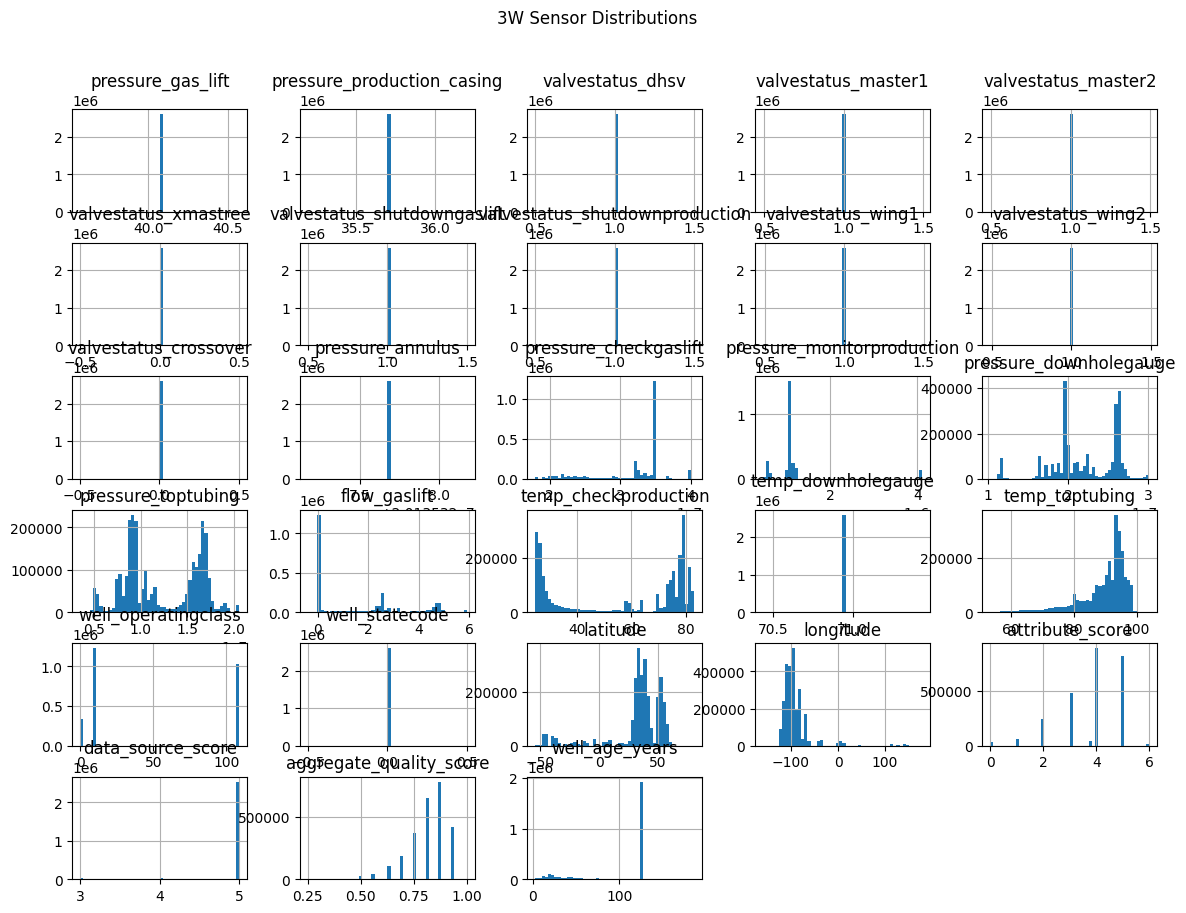

In [10]:
df_3w.select_dtypes(include="number").hist(
    figsize=(14, 10),
    bins=50
)
plt.suptitle("3W Sensor Distributions")
plt.show()


In [6]:
print(df_3w.columns.tolist())

['pressure_gas_lift', 'pressure_production_casing', 'valvestatus_dhsv', 'valvestatus_master1', 'valvestatus_master2', 'valvestatus_xmastree', 'valvestatus_shutdowngaslift', 'valvestatus_shutdownproduction', 'valvestatus_wing1', 'valvestatus_wing2', 'valvestatus_crossover', 'pressure_annulus', 'pressure_checkgaslift', 'pressure_monitorproduction', 'pressure_downholegauge', 'pressure_toptubing', 'flow_gaslift', 'temp_checkproduction', 'temp_downholegauge', 'temp_toptubing', 'well_operatingclass', 'well_statecode', 'category', 'region', 'country', 'state', 'facility_status', 'latitude', 'longitude', 'attribute_score', 'data_source_score', 'update_frequency_score', 'aggregate_quality_score', 'well_age_years']
